## 0. Install / Import Dependencies

In [2]:
# Uncomment if running for the first time
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install pandas numpy matplotlib seaborn scikit-learn tqdm

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl (8.1 MB)


In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.2.2


## 1. Configuration — Edit These

In [8]:
# ─── DATA ────────────────────────────────────────────────────────────────────
DATA_PATH      = 'houston_data.csv'   # Houston accidents CSV
DATETIME_COL   = 'Start_Time'
SEVERITY_COL   = 'Severity'

# ─── DATE FILTER — pre-COVID only ────────────────────────────────────────────
DATE_CUTOFF    = '2019-12-31'

# ─── AGGREGATION ─────────────────────────────────────────────────────────────
FREQ           = 'D'     # Daily
TARGET         = 'count' # 'count' = accidents per day  |  'severity' = mean severity

# ─── SEQUENCE ────────────────────────────────────────────────────────────────
SEQ_LEN        = 30      # 30-day lookback window
PRED_HORIZON   = 7       # forecast 1 week ahead

# ─── TRAIN / VAL / TEST SPLIT ────────────────────────────────────────────────
TRAIN_END      = '2018-12-31'   # ~2.5 years training
VAL_END        = '2019-06-30'   # 6 months validation
# Test          = 2019-07-01 → 2019-12-31  (~6 months)

# ─── MODEL ───────────────────────────────────────────────────────────────────
MODEL_TYPE     = 'LSTM'
HIDDEN_SIZE    = 128
NUM_LAYERS     = 2
DROPOUT        = 0.3

# ─── TRAINING ────────────────────────────────────────────────────────────────
EPOCHS         = 50
BATCH_SIZE     = 64
LEARNING_RATE  = 1e-3

Configuration loaded ✓


## 2. Load & Explore Raw Data

In [9]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)


Raw shape: (169609, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-261020,Source2,2,2016-11-30 16:08:57,2016-11-30 17:30:00,29.716625,-95.551613,NaN,NaN,0.00,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-261021,Source2,2,2016-11-30 15:52:28,2016-11-30 17:22:16,29.859201,-95.403114,NaN,NaN,0.00,...,False,False,True,False,True,False,Day,Day,Day,Day
2,A-261022,Source2,2,2016-11-30 16:37:00,2016-11-30 17:36:49,29.845549,-95.384483,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [10]:
# Parse datetime — houston_data uses mixed format (some rows have nanoseconds)
df_raw[DATETIME_COL] = pd.to_datetime(df_raw[DATETIME_COL], format='mixed')
df = df_raw.dropna(subset=[DATETIME_COL, SEVERITY_COL]).copy()

# Filter to pre-COVID data
df = df[df[DATETIME_COL] <= DATE_CUTOFF]
print(f"After date cutoff (≤ {DATE_CUTOFF}): {len(df):,} records")

df = df.sort_values(DATETIME_COL)
print(f"Date range  : {df[DATETIME_COL].min()} → {df[DATETIME_COL].max()}")
print(f"Total rows  : {len(df):,}")
print(f"\nSeverity distribution:")
print(df[SEVERITY_COL].value_counts().sort_index())
print(f"\nWeather column null rates:")
wx_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition']
for c in wx_cols:
    print(f"  {c:<25}: {df[c].isna().mean()*100:.1f}% null")


After date cutoff (≤ 2019-12-31): 93,285 records
Date range  : 2016-06-14 20:21:49 → 2019-12-30 21:54:18
Total rows  : 93,285

Severity distribution:
Severity
1       48
2    72417
3    20064
4      756
Name: count, dtype: int64

Weather column null rates:
  Temperature(F)           : 2.3% null
  Humidity(%)              : 2.3% null
  Visibility(mi)           : 2.2% null
  Wind_Speed(mph)          : 14.0% null
  Precipitation(in)        : 77.0% null
  Weather_Condition        : 2.4% null


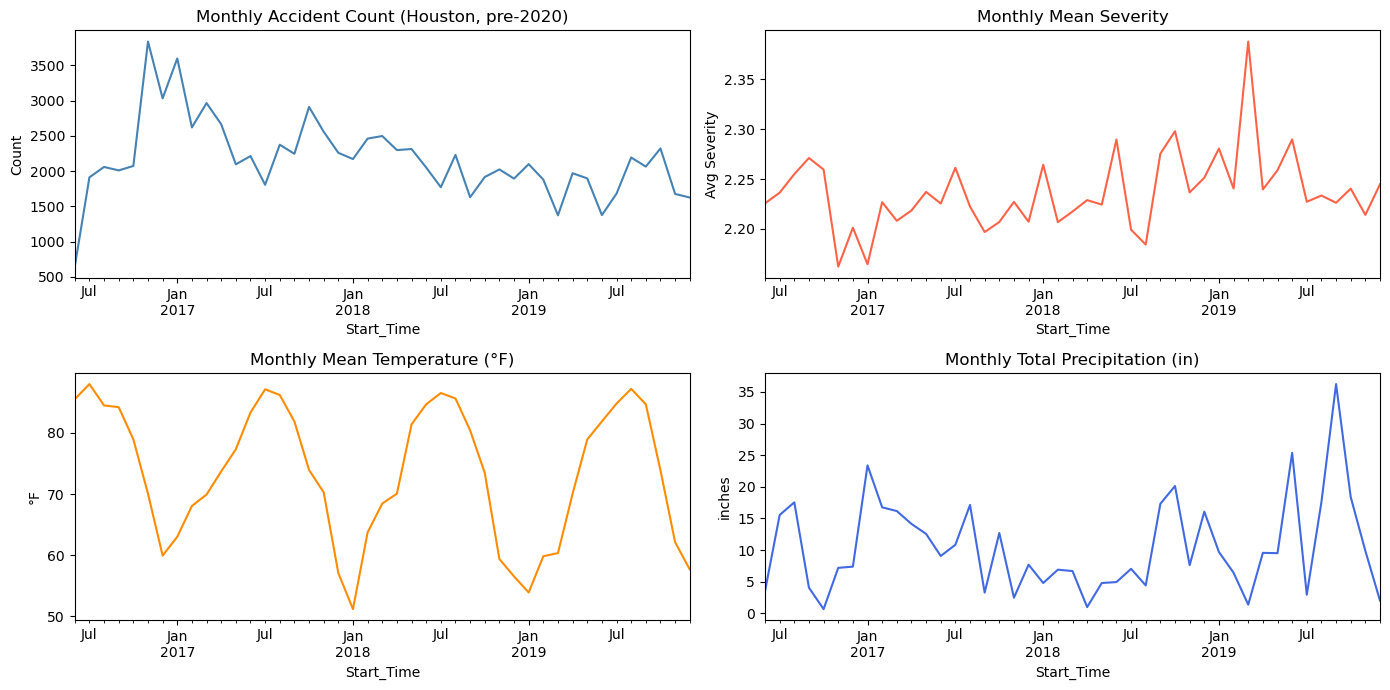

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

monthly = df.set_index(DATETIME_COL).resample('ME')
monthly[SEVERITY_COL].count().plot(ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Monthly Accident Count (Houston, pre-2020)')
axes[0,0].set_ylabel('Count')

monthly[SEVERITY_COL].mean().plot(ax=axes[0,1], color='tomato')
axes[0,1].set_title('Monthly Mean Severity')
axes[0,1].set_ylabel('Avg Severity')

monthly['Temperature(F)'].mean().plot(ax=axes[1,0], color='darkorange')
axes[1,0].set_title('Monthly Mean Temperature (°F)')
axes[1,0].set_ylabel('°F')

monthly['Precipitation(in)'].sum().plot(ax=axes[1,1], color='royalblue')
axes[1,1].set_title('Monthly Total Precipitation (in)')
axes[1,1].set_ylabel('inches')

plt.tight_layout()
plt.show()


## 3. Time-Series Aggregation (with Weather Features)


In [12]:
df_indexed = df.set_index(DATETIME_COL)

# ── Accident target columns ───────────────────────────────────────────────────
ts_count    = df_indexed[SEVERITY_COL].resample(FREQ).count().rename('accident_count')
ts_severity = df_indexed[SEVERITY_COL].resample(FREQ).mean().rename('mean_severity')
ts_severe   = (df_indexed[SEVERITY_COL] >= 3).resample(FREQ).sum().rename('severe_count')

# ── Weather aggregations ──────────────────────────────────────────────────────
# Precipitation: fill NaN with 0 first (missing = no rain recorded)
df_indexed['Precipitation(in)'] = df_indexed['Precipitation(in)'].fillna(0)

ts_temp    = df_indexed['Temperature(F)'].resample(FREQ).mean().rename('mean_temp')
ts_humid   = df_indexed['Humidity(%)'].resample(FREQ).mean().rename('mean_humidity')
ts_vis     = df_indexed['Visibility(mi)'].resample(FREQ).mean().rename('mean_visibility')
ts_wind    = df_indexed['Wind_Speed(mph)'].resample(FREQ).mean().rename('mean_wind')
ts_precip  = df_indexed['Precipitation(in)'].resample(FREQ).sum().rename('total_precip')
ts_rain_hr = (df_indexed['Precipitation(in)'] > 0).resample(FREQ).sum().rename('rainy_hours')  # hours with any rain

# Bad-visibility days (visibility < 5 miles — fog, heavy rain, haze)
ts_low_vis = (df_indexed['Visibility(mi)'] < 5).resample(FREQ).sum().rename('low_vis_hours')

ts = pd.concat([
    ts_count, ts_severity, ts_severe,
    ts_temp, ts_humid, ts_vis, ts_wind, ts_precip, ts_rain_hr, ts_low_vis,
], axis=1).fillna(0)

# Forward-fill weather on days with no accidents (temp/humidity don't drop to 0)
for col in ['mean_temp', 'mean_humidity', 'mean_visibility', 'mean_wind']:
    ts[col] = ts[col].replace(0, np.nan).ffill().bfill()

# ── Calendar features ─────────────────────────────────────────────────────────
ts['dayofweek']  = ts.index.dayofweek
ts['month']      = ts.index.month
ts['is_weekend'] = (ts.index.dayofweek >= 5).astype(int)
ts['year']       = ts.index.year

# Cyclic encoding
ts['dow_sin']   = np.sin(2 * np.pi * ts['dayofweek'] / 7)
ts['dow_cos']   = np.cos(2 * np.pi * ts['dayofweek'] / 7)
ts['month_sin'] = np.sin(2 * np.pi * ts['month']     / 12)
ts['month_cos'] = np.cos(2 * np.pi * ts['month']     / 12)

# ── Lag & rolling features ────────────────────────────────────────────────────
for lag in [1, 7, 30]:
    ts[f'count_lag_{lag}']    = ts['accident_count'].shift(lag)
    ts[f'severity_lag_{lag}'] = ts['mean_severity'].shift(lag)
    ts[f'severe_lag_{lag}']   = ts['severe_count'].shift(lag)

for w in [7, 30]:
    ts[f'count_roll_mean_{w}']  = ts['accident_count'].rolling(w).mean()
    ts[f'count_roll_std_{w}']   = ts['accident_count'].rolling(w).std()
    ts[f'precip_roll_sum_{w}']  = ts['total_precip'].rolling(w).sum()
    ts[f'temp_roll_mean_{w}']   = ts['mean_temp'].rolling(w).mean()

ts = ts.dropna()
print(f"Aggregated time series shape: {ts.shape}")
print(f"Date range: {ts.index.min().date()} → {ts.index.max().date()}")
ts.head(3)


Aggregated time series shape: (1265, 35)
Date range: 2016-07-14 → 2019-12-30


,accident_count,mean_severity,severe_count,mean_temp,mean_humidity,mean_visibility,mean_wind,total_precip,rainy_hours,low_vis_hours,...,severity_lag_30,severe_lag_30,count_roll_mean_7,count_roll_std_7,precip_roll_sum_7,temp_roll_mean_7,count_roll_mean_30,count_roll_std_30,precip_roll_sum_30,temp_roll_mean_30
Start_Time,,,,,,,,,,,,,,,,,,,,,
2016-07-14,72,2.250000,18,90.047222,57.944444,8.611111,8.685714,0.0,0,0,...,2.0,0.0,64.285714,27.890944,0.06,89.131904,49.866667,36.913443,3.58,88.169978
2016-07-15,53,2.339623,18,93.873585,46.754717,8.339623,9.654167,0.0,0,0,...,0.0,0.0,60.571429,27.330430,0.06,89.950373,51.633333,35.692637,3.58,88.462431
2016-07-16,33,2.212121,7,89.712121,56.818182,9.939394,7.454545,0.0,0,0,...,0.0,0.0,61.285714,26.386324,0.00,89.911288,52.733333,34.536271,3.58,88.616168


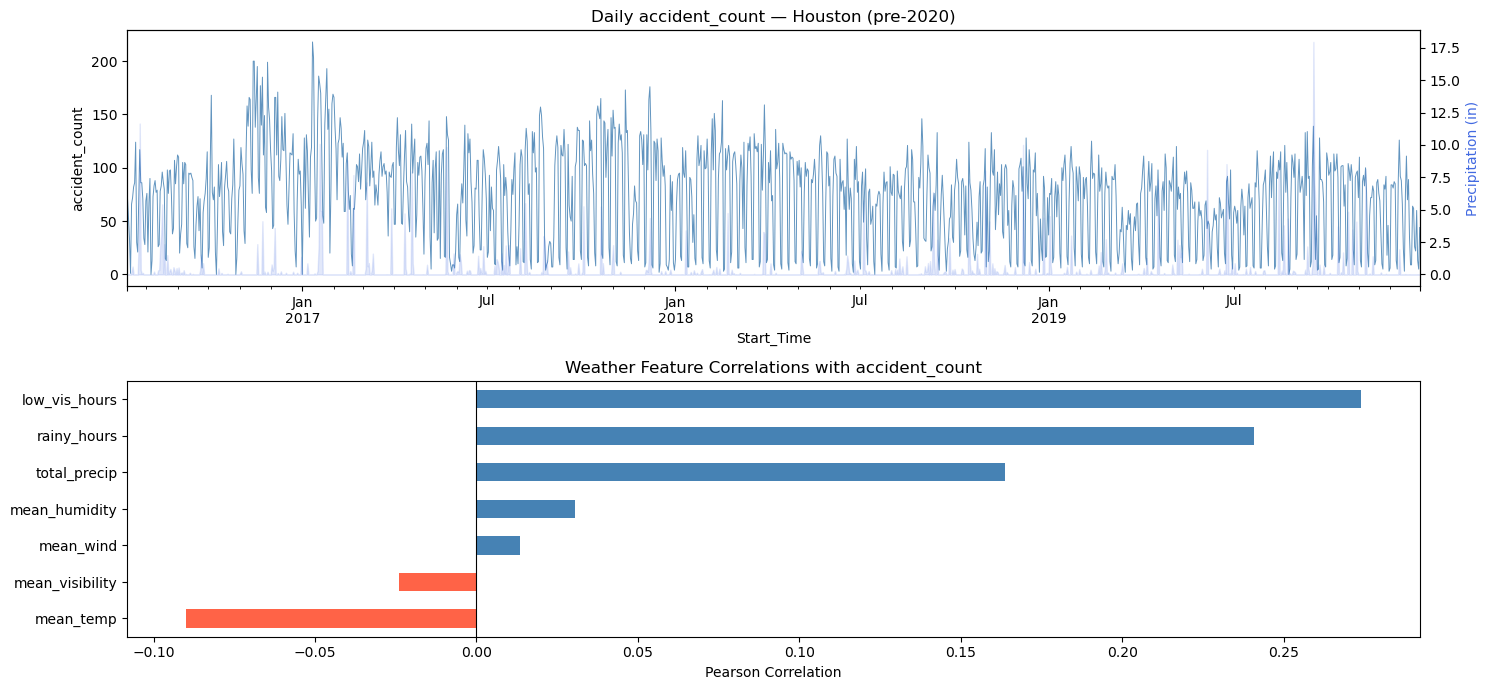


Correlations with accident_count
mean_temp         -0.090
mean_visibility   -0.024
mean_wind          0.014
mean_humidity      0.031
total_precip       0.164
rainy_hours        0.241
low_vis_hours      0.274
Name: accident_count, dtype: float64


In [13]:
target_col = 'accident_count' if TARGET == 'count' else 'mean_severity'

fig, axes = plt.subplots(2, 1, figsize=(15, 7))

ts[target_col].plot(ax=axes[0], linewidth=0.7, color='steelblue', alpha=0.85)
axes[0].set_title(f'Daily {target_col} — Houston (pre-2020)')
axes[0].set_ylabel(target_col)

# Overlay precipitation as bar chart
ax2 = axes[0].twinx()
ts['total_precip'].plot(ax=ax2, color='royalblue', alpha=0.3, linewidth=0)
ax2.fill_between(ts.index, ts['total_precip'], alpha=0.15, color='royalblue')
ax2.set_ylabel('Precipitation (in)', color='royalblue')

# Weather correlations with accident count
wx_features = ['mean_temp', 'mean_humidity', 'mean_visibility', 'mean_wind', 'total_precip', 'rainy_hours', 'low_vis_hours']
corrs = ts[wx_features + [target_col]].corr()[target_col].drop(target_col).sort_values()
corrs.plot(kind='barh', ax=axes[1], color=['tomato' if v < 0 else 'steelblue' for v in corrs])
axes[1].set_title(f'Weather Feature Correlations with {target_col}')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

print('\nCorrelations with', target_col)
print(corrs.round(3))


## 4. Feature Selection & Scaling

In [14]:
FEATURE_COLS = [
    # ── Targets & derived counts ──────────────────────────────────────────────
    'accident_count', 'mean_severity', 'severe_count',
    # ── Weather ───────────────────────────────────────────────────────────────
    'mean_temp', 'mean_humidity', 'mean_visibility',
    'mean_wind', 'total_precip', 'rainy_hours', 'low_vis_hours',
    # ── Calendar ──────────────────────────────────────────────────────────────
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend',
    # ── Lag features ──────────────────────────────────────────────────────────
    'count_lag_1', 'count_lag_7', 'count_lag_30',
    'severity_lag_1', 'severity_lag_7', 'severity_lag_30',
    'severe_lag_1', 'severe_lag_7', 'severe_lag_30',
    # ── Rolling features ──────────────────────────────────────────────────────
    'count_roll_mean_7', 'count_roll_std_7',
    'count_roll_mean_30', 'count_roll_std_30',
    'precip_roll_sum_7', 'precip_roll_sum_30',
    'temp_roll_mean_7', 'temp_roll_mean_30',
]

TARGET_COL = 'accident_count' if TARGET == 'count' else 'mean_severity'

data = ts[FEATURE_COLS].values.astype(np.float32)
target_idx = FEATURE_COLS.index(TARGET_COL)

# Fit scaler on training data only — prevents leakage
train_mask = ts.index <= TRAIN_END
scaler = MinMaxScaler()
scaler.fit(data[train_mask])
data_scaled = scaler.transform(data)

print(f"Feature matrix shape : {data_scaled.shape}")
print(f"Target column index  : {target_idx} ({TARGET_COL})")
print(f"Weather features     : mean_temp, mean_humidity, mean_visibility, mean_wind,")
print(f"                       total_precip, rainy_hours, low_vis_hours")


Feature matrix shape : (1265, 32)
Target column index  : 0 (accident_count)
Weather features     : mean_temp, mean_humidity, mean_visibility, mean_wind,
                       total_precip, rainy_hours, low_vis_hours


## 5. Sequence Dataset

In [18]:
class AccidentSequenceDataset(Dataset):
    """
    Returns (X, y) pairs where:
      X : (SEQ_LEN, n_features)  — historical window
      y : (PRED_HORIZON,)        — future target values
    """
    def __init__(self, data: np.ndarray, seq_len: int, pred_horizon: int, target_idx: int):
        self.data         = torch.tensor(data, dtype=torch.float32)
        self.seq_len      = seq_len
        self.pred_horizon = pred_horizon
        self.target_idx   = target_idx

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_horizon + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]                                     # (seq_len, features)
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_horizon,
                      self.target_idx]                                               # (pred_horizon,)
        return x, y


# ── Train / Val / Test split (chronological — no shuffling) ──────────────────
train_mask = ts.index <= TRAIN_END
val_mask   = (ts.index > TRAIN_END) & (ts.index <= VAL_END)
test_mask  = ts.index > VAL_END

train_end_pos = np.where(train_mask)[0][-1] + 1
val_end_pos   = np.where(val_mask)[0][-1]   + 1

train_data = data_scaled[:train_end_pos]
val_data   = data_scaled[train_end_pos - SEQ_LEN : val_end_pos]
test_data  = data_scaled[val_end_pos   - SEQ_LEN : ]

train_ds = AccidentSequenceDataset(train_data, SEQ_LEN, PRED_HORIZON, target_idx)
val_ds   = AccidentSequenceDataset(val_data,   SEQ_LEN, PRED_HORIZON, target_idx)
test_ds  = AccidentSequenceDataset(test_data,  SEQ_LEN, PRED_HORIZON, target_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train sequences : {len(train_ds):,}")
print(f"Val   sequences : {len(val_ds):,}")
print(f"Test  sequences : {len(test_ds):,}")

# Sanity check shapes
xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape}  →  Batch y: {yb.shape}")

Train sequences : 865
Val   sequences : 175
Test  sequences : 177
Batch X: torch.Size([64, 30, 32])  →  Batch y: torch.Size([64, 7])


## 6. Model Definition — LSTM

In [19]:
class RNNForecaster(nn.Module):
    """
    Flexible LSTM or GRU forecaster.
    Input  : (batch, seq_len, n_features)
    Output : (batch, pred_horizon)
    """
    def __init__(
        self,
        model_type:   str,
        input_size:   int,
        hidden_size:  int,
        num_layers:   int,
        pred_horizon: int,
        dropout:      float = 0.2,
    ):
        super().__init__()
        self.model_type = model_type.upper()

        rnn_cls = nn.LSTM if self.model_type == 'LSTM' else nn.GRU
        self.rnn = rnn_cls(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            batch_first  = True,
            dropout      = dropout if num_layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, pred_horizon),
        )

    def forward(self, x):
        # x: (B, T, F)
        out, _ = self.rnn(x)        # out: (B, T, H)
        last    = out[:, -1, :]     # take last timestep: (B, H)
        last    = self.norm(last)
        return self.head(last)      # (B, pred_horizon)


N_FEATURES = data_scaled.shape[1]

model = RNNForecaster(
    model_type   = MODEL_TYPE,
    input_size   = N_FEATURES,
    hidden_size  = HIDDEN_SIZE,
    num_layers   = NUM_LAYERS,
    pred_horizon = PRED_HORIZON,
    dropout      = DROPOUT,
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

RNNForecaster(
  (rnn): LSTM(32, 128, num_layers=2, batch_first=True, dropout=0.3)
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=7, bias=True)
  )
)

Trainable parameters: 224,007


## 7. Training Loop

In [20]:
criterion  = nn.HuberLoss()                        # robust to outlier spikes
optimizer  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5, verbose=True
)


def run_epoch(loader, train: bool):
    model.train() if train else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds  = model(xb)
            loss   = criterion(preds, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


train_losses, val_losses = [], []
best_val_loss = float('inf')
best_weights  = None

for epoch in tqdm(range(1, EPOCHS + 1), desc='Training'):
    tr_loss = run_epoch(train_loader, train=True)
    vl_loss = run_epoch(val_loader,   train=False)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    scheduler.step(vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f}")

# Restore best checkpoint
model.load_state_dict(best_weights)
print(f"\nBest validation loss: {best_val_loss:.4f}")

Training:  20%|██████▌                          | 10/50 [00:04<00:17,  2.27it/s]

Epoch  10 | Train Loss: 0.0168 | Val Loss: 0.0071


Training:  40%|█████████████▏                   | 20/50 [00:08<00:12,  2.36it/s]

Epoch  20 | Train Loss: 0.0131 | Val Loss: 0.0053


Training:  60%|███████████████████▊             | 30/50 [00:13<00:08,  2.41it/s]

Epoch  30 | Train Loss: 0.0115 | Val Loss: 0.0043


Training:  80%|██████████████████████████▍      | 40/50 [00:17<00:04,  2.38it/s]

Epoch  40 | Train Loss: 0.0097 | Val Loss: 0.0040


Training: 100%|█████████████████████████████████| 50/50 [00:21<00:00,  2.30it/s]

Epoch  50 | Train Loss: 0.0097 | Val Loss: 0.0040

Best validation loss: 0.0037


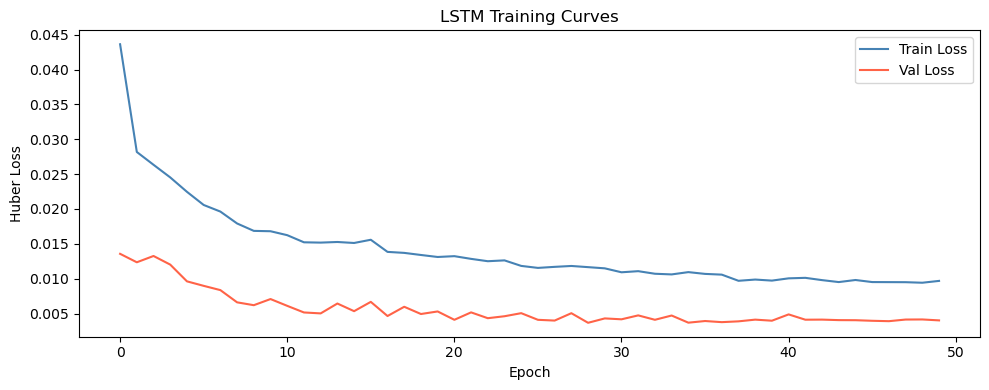

In [21]:
# Loss curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(val_losses,   label='Val Loss',   color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.set_title(f'{MODEL_TYPE} Training Curves')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

In [23]:
def predict_all(loader):
    model.eval()
    preds_all, targets_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            p = model(xb.to(DEVICE)).cpu().numpy()
            preds_all.append(p)
            targets_all.append(yb.numpy())
    return np.vstack(preds_all), np.vstack(targets_all)


preds_scaled, actuals_scaled = predict_all(test_loader)

# Inverse-transform only the target dimension
def inverse_target(scaled_vals: np.ndarray) -> np.ndarray:
    """Inverse-scale a (N, H) array of target values."""
    dummy = np.zeros((scaled_vals.size, N_FEATURES), dtype=np.float32)
    dummy[:, target_idx] = scaled_vals.ravel()
    inv = scaler.inverse_transform(dummy)[:, target_idx]
    return inv.reshape(scaled_vals.shape)

preds   = inverse_target(preds_scaled)
actuals = inverse_target(actuals_scaled)

# Flatten for overall metrics
p_flat = preds.ravel()
a_flat = actuals.ravel()

mae  = mean_absolute_error(a_flat, p_flat)
rmse = np.sqrt(mean_squared_error(a_flat, p_flat))
r2   = r2_score(a_flat, p_flat)

print(f"{'Metric':<10} {'Value':>10}")
print("-" * 22)
print(f"{'MAE':<10} {mae:>10.3f}")
print(f"{'RMSE':<10} {rmse:>10.3f}")
print(f"{'R²':<10} {r2:>10.4f}")

Metric          Value
----------------------
MAE            18.337
RMSE           23.253
R²             0.6402


## 9. Visualising Predictions

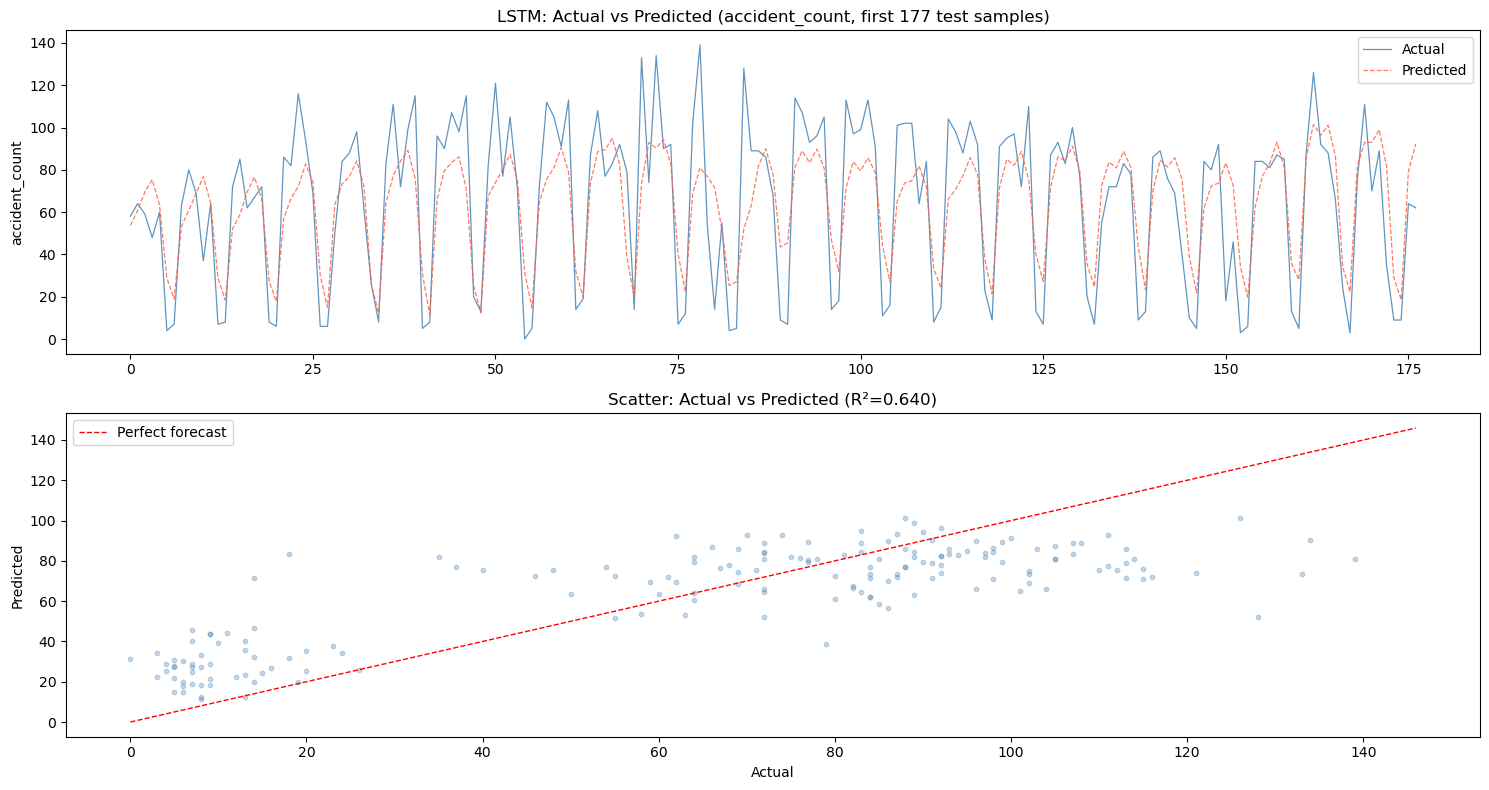

In [24]:
# ── 1-step-ahead slice (first step of each multi-step prediction) ─────────────
n_plot   = min(500, len(preds))
pred_1st = preds[:n_plot, 0]    # first horizon step
act_1st  = actuals[:n_plot, 0]

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Time-series overlay
axes[0].plot(act_1st,  label='Actual',    color='steelblue', linewidth=0.9, alpha=0.85)
axes[0].plot(pred_1st, label='Predicted', color='tomato',    linewidth=0.9, alpha=0.85, linestyle='--')
axes[0].set_title(f'{MODEL_TYPE}: Actual vs Predicted ({TARGET_COL}, first {n_plot} test samples)')
axes[0].set_ylabel(TARGET_COL)
axes[0].legend()

# Scatter
lim_max = max(act_1st.max(), pred_1st.max()) * 1.05
axes[1].scatter(act_1st, pred_1st, alpha=0.3, s=10, color='steelblue')
axes[1].plot([0, lim_max], [0, lim_max], 'r--', linewidth=1, label='Perfect forecast')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Scatter: Actual vs Predicted (R²={r2:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

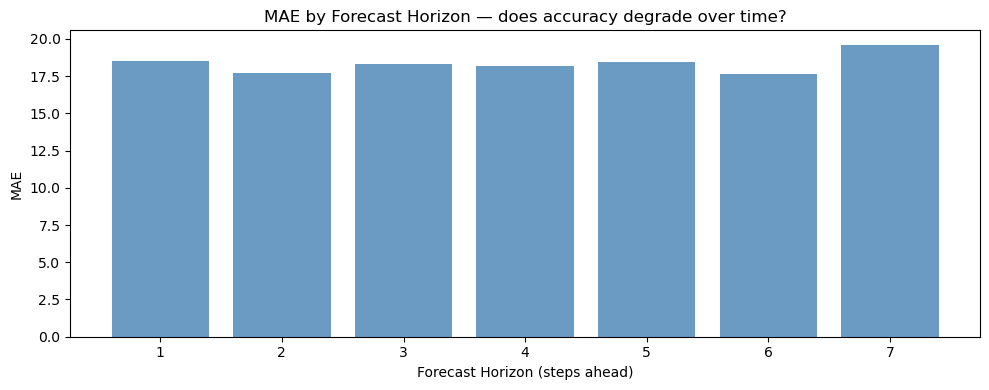

In [25]:
# ── Multi-horizon error analysis ──────────────────────────────────────────────
horizon_mae = [mean_absolute_error(actuals[:, h], preds[:, h]) for h in range(PRED_HORIZON)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, PRED_HORIZON + 1), horizon_mae, color='steelblue', alpha=0.8)
ax.set_xlabel('Forecast Horizon (steps ahead)')
ax.set_ylabel('MAE')
ax.set_title('MAE by Forecast Horizon — does accuracy degrade over time?')
plt.tight_layout()
plt.show()

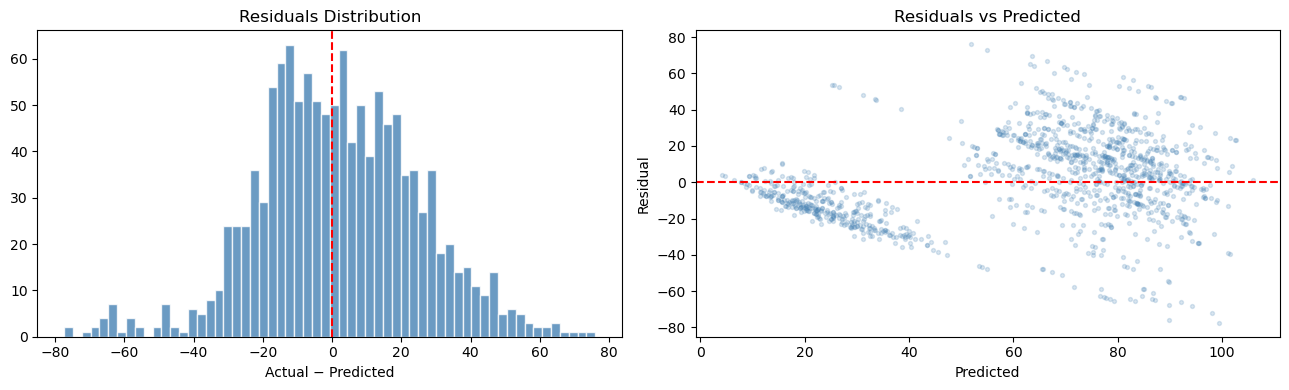

In [26]:
# ── Residuals distribution ─────────────────────────────────────────────────────
residuals = a_flat - p_flat

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Distribution')
axes[0].set_xlabel('Actual − Predicted')

axes[1].scatter(p_flat, residuals, alpha=0.2, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## 10. LSTM vs GRU Side-by-Side Comparison

In [27]:
def train_model(model_type: str, epochs: int = EPOCHS, verbose: bool = False):
    """Helper: train a fresh model and return test metrics."""
    m = RNNForecaster(
        model_type   = model_type,
        input_size   = N_FEATURES,
        hidden_size  = HIDDEN_SIZE,
        num_layers   = NUM_LAYERS,
        pred_horizon = PRED_HORIZON,
        dropout      = DROPOUT,
    ).to(DEVICE)
    opt  = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE)
    crit = nn.HuberLoss()
    best_val, best_w = float('inf'), None

    for ep in range(1, epochs + 1):
        # train
        m.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(m(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
        # validate
        m.eval(); vl = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                vl += crit(m(xb.to(DEVICE)), yb.to(DEVICE)).item() * xb.size(0)
        vl /= len(val_loader.dataset)
        if vl < best_val:
            best_val = vl
            best_w   = {k: v.cpu().clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_w)
    p, a = predict_all(test_loader)
    p, a = inverse_target(p).ravel(), inverse_target(a).ravel()
    return {
        'MAE':  mean_absolute_error(a, p),
        'RMSE': np.sqrt(mean_squared_error(a, p)),
        'R2':   r2_score(a, p),
        'MAPE': np.mean(np.abs((a - p) / (a + 1e-6))) * 100,
    }

print("Training LSTM...")
lstm_metrics = train_model('LSTM')
print("Training GRU...")
gru_metrics  = train_model('GRU')

comparison = pd.DataFrame({'LSTM': lstm_metrics, 'GRU': gru_metrics})
print("\n", comparison.round(4))

Training LSTM...
Training GRU...

               LSTM           GRU
MAE   1.833680e+01  1.833680e+01
RMSE  2.325270e+01  2.325270e+01
R2    6.402000e-01  6.402000e-01
MAPE  1.235288e+07  1.235288e+07


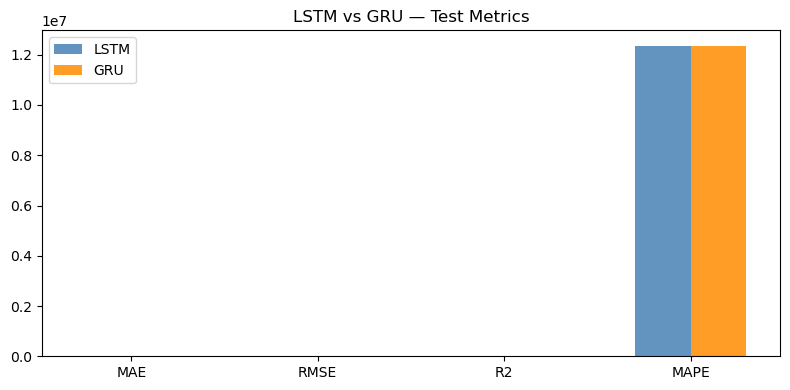

In [28]:
# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
x   = np.arange(len(comparison.index))
w   = 0.3
ax.bar(x - w/2, comparison['LSTM'], width=w, label='LSTM', color='steelblue', alpha=0.85)
ax.bar(x + w/2, comparison['GRU'],  width=w, label='GRU',  color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(comparison.index)
ax.set_title('LSTM vs GRU — Test Metrics')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Multi-Step Forecast Demo

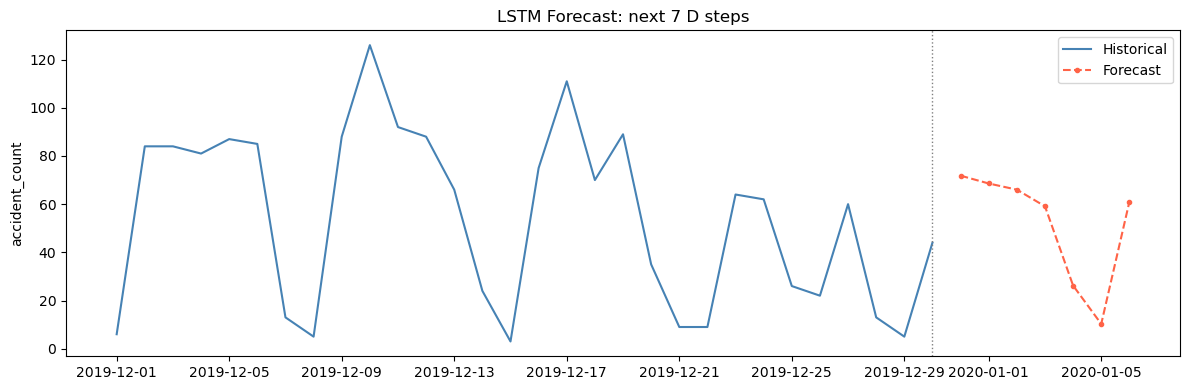


Forecast values:
  2019-12-31 00:00:00  →  71.82
  2020-01-01 00:00:00  →  68.57
  2020-01-02 00:00:00  →  66.02
  2020-01-03 00:00:00  →  59.11
  2020-01-04 00:00:00  →  26.19
  2020-01-05 00:00:00  →  10.28
  2020-01-06 00:00:00  →  60.95


In [29]:
def forecast_next_window(model, data_scaled, seq_len, pred_horizon, scaler, target_idx, n_features):
    """Produce a multi-step forecast from the very last window of available data."""
    model.eval()
    last_window = data_scaled[-seq_len:]                           # (seq_len, n_features)
    x = torch.tensor(last_window, dtype=torch.float32).unsqueeze(0).to(DEVICE)  # (1, T, F)
    with torch.no_grad():
        pred_scaled = model(x).cpu().numpy()                       # (1, pred_horizon)
    return inverse_target(pred_scaled).ravel()                     # (pred_horizon,)


forecast = forecast_next_window(model, data_scaled, SEQ_LEN, PRED_HORIZON, scaler, target_idx, N_FEATURES)

# Build a future date index
last_ts  = ts.index[-1]
freq_map = {'H': 'h', 'D': 'D', 'W': 'W'}  # pandas freq aliases
future_idx = pd.date_range(start=last_ts, periods=PRED_HORIZON + 1, freq=freq_map.get(FREQ, FREQ))[1:]

# Show recent history + forecast
history_window = 7 * 24 if FREQ == 'H' else 30   # 1 week for hourly, 30 steps otherwise
hist_vals = inverse_target(data_scaled[-history_window:, target_idx:target_idx+1].T)[0]
hist_idx  = ts.index[-history_window:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hist_idx,   hist_vals, color='steelblue', label='Historical')
ax.plot(future_idx, forecast,  color='tomato',    linestyle='--', marker='o', markersize=3, label='Forecast')
ax.axvline(last_ts, color='gray', linestyle=':', linewidth=1)
ax.set_title(f'{MODEL_TYPE} Forecast: next {PRED_HORIZON} {FREQ} steps')
ax.set_ylabel(TARGET_COL)
ax.legend()
plt.tight_layout()
plt.show()

print("\nForecast values:")
for ts_idx, val in zip(future_idx, forecast):
    print(f"  {ts_idx}  →  {val:.2f}")